In [ ]:
%matplotlib inline
%run demo/demo_fem/demo_constrained_function_space.py

In [ ]:
%matplotlib inline
!mpirun -np 10 python3 -u work/debug_constrained_function_space/debug1.py

In [ ]:
%matplotlib inline
!mpirun -np 1 python3 -u work/debug_constrained_function_space/debug2.py

# GMSH Meshing 

In [ ]:
import gmsh
import numpy as np

# Initialize GMSH
gmsh.initialize()

# Open the existing GMSH mesh file
mesh_file = "mymesh.msh"
try:
    gmsh.open(mesh_file)
except Exception as e:
    print(f"Error loading mesh file: {e}")
    gmsh.finalize()
    exit()

# Ensure the mesh is generated (in case it's only geometry)
gmsh.model.mesh.generate(3)  # 3D mesh generation (use 2 for 2D)

# Get the volume entities (tags for volumes in the mesh)
volume_tags = gmsh.model.getEntities(dim=3)  # Get 3D entities (volumes)

# Get the elements (for volume elements)
elements_by_volume = {}
for volume_tag, _ in volume_tags:
    # Get elements of the specific volume (use dim=3 for 3D volume elements)
    element_types, element_tags, element_node_tags = gmsh.model.mesh.getElements(dim=3, tag=volume_tag)
    elements_by_volume[volume_tag] = (element_types, element_tags, element_node_tags)

# Get the node tags and coordinates
node_tags, node_coords, _ = gmsh.model.mesh.getNodes()

# Ensure that the mesh contains nodes
if len(node_tags) == 0:
    print("Error: No nodes found in the mesh!")
    gmsh.finalize()
    exit()

# Convert node coordinates into a NumPy array for easier manipulation
node_coords = np.array(node_coords).reshape(-1, 3)  # Use reshape (num_nodes, 3) for 3D mesh (2D mesh will be reshaped accordingly)

# Number of copies and translation distance
num_copies = 3
offset_x = 10  # Distance between copies along the X-axis

# Store new nodes and elements
new_node_tags = list(node_tags)  # Start with the original node tags
new_node_coords = node_coords.tolist()  # Start with the original coordinates
new_element_types = []
new_element_tags = []
new_element_nodes = []

max_node_tag = max(node_tags)  # Get the highest node ID to avoid duplicates

# Loop over the number of copies and duplicate each volume
for i in range(1, num_copies):
    dx = i * offset_x  # Translation in the X direction (you can modify this to translate along other axes)

    # Shift node coordinates for each copy
    shifted_coords = node_coords + np.array([dx, 0, 0])

    # Generate new node tags for this copy
    new_tags = np.arange(max_node_tag + 1, max_node_tag + 1 + len(node_tags))
    max_node_tag = new_tags[-1]  # Update the highest node tag

    # Append new nodes
    new_node_tags.extend(new_tags)
    new_node_coords.extend(shifted_coords.tolist())  # Add the shifted coordinates

    # Adjust element connectivity for each volume (translate the node IDs for each element)
    for volume_tag, (element_types, element_tags, element_node_tags) in elements_by_volume.items():
        for el_type, el_tags, el_nodes in zip(element_types, element_tags, element_node_tags):
            # Adjust node IDs by adding the offset based on the number of copies
            new_elements = (np.array(el_nodes) + len(node_tags) * i).tolist()
            new_element_types.append(el_type)
            new_element_tags.append(el_tags)
            new_element_nodes.append(new_elements)

# Create a new model for the repeated mesh
gmsh.model.add("repeated_mesh")

# Add the new nodes (flatten the coordinates before adding them)
new_node_coords_flat = np.array(new_node_coords).flatten()  # Flatten for GMSH input
gmsh.model.mesh.addNodes(3, new_node_tags, new_node_coords_flat)  # 3D mesh (use 2 for 2D mesh)

# Add the new elements (volume, surface, etc.)
for el_type, el_nodes in zip(new_element_types, new_element_nodes):
    gmsh.model.mesh.addElements(3, [el_type], [el_nodes])  # 3D elements (adjust if 2D mesh)

# Write the new repeated mesh to a file
gmsh.write("repeated_mesh_with_volumes.msh")

# Finalize GMSH
gmsh.finalize()
print(" Repeated mesh saved as: repeated_mesh_with_volumes.msh")


In [ ]:
import gmsh
import numpy as np

# Initialize GMSH
gmsh.initialize()

# Open the existing GMSH mesh file
mesh_file = "mymesh.msh"
try:
    gmsh.open(mesh_file)
except Exception as e:
    print(f"Error loading mesh file: {e}")
    gmsh.finalize()
    exit()

(nodes, coords, _) = gmsh.model.mesh.getNodes()

# scale doesn't really work nicely unless the model's centered
for i, tag in enumerate(nodes):
        gmsh.model.mesh.setNode(tag, [coords[3*i] + 1.0, coords[3*i+1] + 0.0, coords[3*i+2]], [])

gmsh.write("transformed.msh")
gmsh.finalize()


In [ ]:
import meshio, gmsh
print(meshio.__version__)
print(gmsh.__version__)

# Eikonal equation

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
max cell size: 0.10054747729448475
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Max distance: 1.298459852198518


/usr/local/lib/python3.6/dist-packages/dolfin/common/plotting.py:152: UserWarning: The following kwargs were not used by contour: 'interactive'
  return ax.tricontourf(mesh2triang(mesh), C, levels, **kwargs)


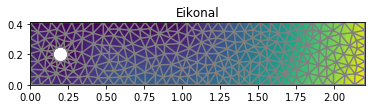

In [1]:
from dolfin import *
import math
from mshr import *

xmin = 0.0
xmax = 2.2
ymin = 0.0
ymax = 0.41

xcenter = 0.2
ycenter = 0.2
radius = 0.05

domain = Rectangle(Point(xmin,ymin),Point(xmax,ymax)) \
- Circle(Point(xcenter,ycenter),radius,12)

mesh = generate_mesh(domain,20)
plot(mesh, "2D mesh")

V = FunctionSpace(mesh, 'CG', 1)
v = TestFunction(V)
u = TrialFunction(V)
f = Constant(1.0)
y = Function(V)

class DolphinBoundary(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and ((x[0]-0.5)**2+(x[1]-0.5)**2) < 0.25

boundary = DolphinBoundary()
bc = DirichletBC(V, Constant(0.0), boundary)

# Initialization problem to get good initial guess for nonlinear problem:
F1 = inner(grad(u), grad(v))*dx - f*v*dx
solve(lhs(F1)==rhs(F1), y, bc)

# Stabilized Eikonal equation 
print("max cell size:", mesh.hmax())
eps = Constant(mesh.hmax()/25)
F = sqrt(inner(grad(y), grad(y)))*v*dx - f*v*dx + eps*inner(grad(y), grad(v))*dx
solve(F==0, y, bc)

print("Max distance:", y.vector().max())

plot(y, rescale=True, title="Eikonal", interactive=True)

# ALM Parameters

In [ ]:
eps0 = eps= 0.05;
sigma=0.01; tau=0.5

for i in range(0, 15):
    sigma = sigma/0.5
    omega = min(0.1, 1/(2*sigma))
    eps = eps0*omega**0.1
    print(i, sigma, eps, omega)
    
    
for i in range(0, 15):
    sigma = sigma
    omega = min(0.1, 1/(2*sigma))
    eps = eps*omega**0.1
    print(i, sigma, eps, omega)

# TIME OUT Attempts

In [ ]:
import time

import multiprocessing as mp
def repeat_until_time_out(seconds_before_timeout, max_no_attempts):
    def repeat_until_time_out_decorator(func):
        result_queue = mp.Queue()
        def func_wrapper(*args, **kwargs):
            try:
                result = func(*args, **kwargs)
                result_queue.put(result)
            except Exception as e:
                result_queue.put(e)        
        def wrapper(*args, **kwargs):
            attempt = 0
            succeeded = False
            while (not succeeded) and (attempt < max_no_attempts):
                process = mp.Process(target=func_wrapper, args=args, kwargs=kwargs)
                process.start()
                process.join(timeout=seconds_before_timeout)
                if process.is_alive():
                    process.terminate()
                    # process.kill()
                    #process.join()
                    funct_name = func.__name__
                    print("multiprocessing {} attempt {} failed due to time out after {} seconds.".format(funct_name, attempt, seconds_before_timeout))
                else:
                    succeeded = True
                attempt += 1
            result = result_queue.get()
            if isinstance(result, Exception):
                raise result
            return result
        return wrapper
    return repeat_until_time_out_decorator

#@repeat_until_time_out(3, 3) 
def countit(p,q=2):
    import time
    for k in range(p**q):
        print(k)
        time.sleep(1)   
    return "geert", 1
a = repeat_until_time_out(11, 3) (countit)(10,1)
print(a)
#foop_with_timeout(timeout=4)



In [ ]:
import signal
import time
from dolfin import *
import dolfin as df

def timeout_handler(num, stack):
    print("Received SIGALRM")
    raise Exception("TIMEOUT")
signal.signal(signal.SIGALRM, timeout_handler)


import h5py
import os
root = os.environ["HOME"] + "/shared/FEniCSLab"
root = os.environ["VSC_SCRATCH"] + "/FEniCSLab"
h5_filename =  root + "/work/shape_opt_periodic_unbalanced_hex_3D_seg/results_hpc8/remesh/mymesh_mesha58cf962-2d30-4e39-b52f-96473f210e81.h5"
h5_filename =  root + "/work/shape_opt_periodic_unbalanced_hex_3D_seg/results_hpc8/remesh2/mymesh_mesh5752fbbd-214b-440f-967a-2a01eb85cf6e.h5"
mesh_xdmf_filename = h5_filename.replace('.h5', '.xdmf')
f = h5py.File(h5_filename,'r')
for item in f.keys():
    print(item +":", f[item])

signal.alarm(20)
for k in range(300):
    print("Before: %s" % time.strftime("%M:%S"))
    try:
        mesh = df.cpp.mesh.Mesh() #Mesh() #Mesh(MPI.comm_world)
        print("empty mesh created", flush=True)
        with XDMFFile(mesh.mpi_comm(), mesh_xdmf_filename) as file:
             file.read(mesh)
        print(k, mesh.num_cells(), flush=True)
    except Exception as ex:
        print("TIMEOUT")
    finally:
        signal.alarm(0)
    print("After: %s" % time.strftime("%M:%S"))

# FFC bugs

In [ ]:
# No-slip boundary condition for velocity
# NOTE: Projection here is inefficient workaround of issue #489, FFC issue #69
noslip = project(Constant((0, 0)), W.sub(0).collapse())
bc0 = DirichletBC(W.sub(0), noslip, sub_domains, 0)

# Inflow boundary condition for velocity
# NOTE: Projection here is inefficient workaround of issue #489, FFC issue #69
inflow = project(Expression(("-sin(x[1]*pi)", "0.0"), degree=2), W.sub(0).collapse())
bc1 = DirichletBC(W.sub(0), inflow, sub_domains, 1)


In [ ]:

 
    # cellmarker_function = function_from_meshfunction(cellmarker, name="cellmarker")
# myiomanager.write("cellmarker", cellmarker_function, 0.0)

# import numpy as np
# Xspace = ConstrainedFunctionSpace(mesh, df.VectorElement('CG', mesh.ufl_cell(), 1), constrained_domain=constrained_domain)
# noise = df.Function(Xspace, name="noise")
# noise_intensity = 0.02
# noise_values = np.random.uniform(-noise_intensity, noise_intensity, size=noise.vector().get_local().shape) #noise.vector().get_local().shape)
# noise.vector().set_local(noise_values)
# zero_bc = df.DirichletBC(Xspace, df.Constant((0,0,0)), "on_boundary")
# zero_bc.apply(noise.vector())
# df.ALE.move(mesh, noise)
# myiomanager.write("cellmarker", cellmarker_function, 1.0)

# smooth_marked_surface_and_move_mesh(mesh, facetmarker, physical_markers["mid_bottom_markers"])  
# myiomanager.write("cellmarker", cellmarker_function, 2.0)

In [ ]:
from dolfin import *
from ufl import conditional, lt, cos, pi, tanh

mesh = UnitSquareMesh(64, 64)

cellmarker = MeshFunction("size_t", mesh, mesh.topology().dim())
cellmarker.set_all(0)

class Region1(SubDomain):
    def inside(self, x, on_boundary):
        return x[0] <= 0.25

class Region2(SubDomain):
    def inside(self, x, on_boundary):
        return (x[0] >= 0.25) and (x[0] <= 0.5)

class Region3(SubDomain):
    def inside(self, x, on_boundary):
        return x[0] >= 0.5
    
r1 = Region1()
r2 = Region2()
r3 = Region3()

r1.mark(cellmarker, 0)
r2.mark(cellmarker, 1)
r3.mark(cellmarker, 2)    
dx_marked = Measure("dx", domain=mesh, subdomain_data=cellmarker)

V = FunctionSpace(mesh, "CG", 1)
Vv = VectorFunctionSpace(mesh, "CG", 1)

# --- Functions ---
phi = Function(V, name='phi')
n = Function(Vv, name="normal")
kappa = Function(V, name="curvature")

# --- Test and trial functions ---
u = TrialFunction(V)
v = TestFunction(V)

r = TrialFunction(Vv)
w = TestFunction(Vv)

k = TrialFunction(V)
q = TestFunction(V)

# =====================================================
# STEP 1: Laplace solve for phi (LINEAR)
# =====================================================
bc_1= DirichletBC(V, Constant(0),"near(x[0], 0.25)")
bc_2= DirichletBC(V, Constant(0), "near(x[0], 0.5)")

domain_signs = {0: -1.0, 1: 1.0, 2: -1.0}

#Nonlinear Solver
F_phi = sum((0.1*dot(grad(phi), grad(v)) + Constant(s) * v) * dx_marked(i)
            for i, s in domain_signs.items())
solve(F_phi == 0, phi, [bc_1, bc_2])

#Linear Solver
a_phi  = sum( 0.1*dot(grad(u), grad(v)) * dx_marked(i)
            for i, s in domain_signs.items())
L_phi = sum(Constant(s) * v * dx_marked(i)
            for i, s in domain_signs.items())
solve(a_phi == L_phi, phi,  [bc_1, bc_2])

from fenicslab.operators import function_from_meshfunction
sign = function_from_meshfunction(cellmarker, name="domain_sign", mapping=domain_signs)
a_phi = inner(u, v) * dx + 0.0001*inner(grad(u), grad(v)) * dx 
L_phi = sign * v * dx
solve(a_phi == L_phi, phi,  [bc_1, bc_2])

# =====================================================
# STEP 2: Normal projection (LINEAR PROJECTION)
# =====================================================
eps_reg = Constant(1e-8)
gamma = Constant(0.001)

n_approx = grad(phi)/sqrt(dot(grad(phi), grad(phi)) + eps_reg)
a_n = inner(r, w) * dx + gamma * inner(grad(r), grad(w))*dx
L_n = dot(n_approx, w) * dx

solve(a_n == L_n, n)

# =====================================================
# STEP 3: Smoothed Dirac 
# =====================================================
delta_eps = Constant(2*mesh.hmax())

h = CellDiameter(mesh)
delta_eps = 2.0 * CellDiameter(mesh)

h = 0.01

delta = conditional(
    lt(abs(phi), delta_eps),
    (15.0/(16.0*delta_eps)) * (1 - (phi/delta_eps)**2)**2,
    0.0
)

delta = conditional(
    lt(abs(phi), delta_eps),
    0.5/eps * (1.0 + cos(pi*phi/delta_eps)),
    0.0
)

delta = 1.0/(sqrt(pi)*delta_eps) * exp(-(phi/delta_eps)**2)

#delta = 0.5/delta_eps * (1.0 - tanh(phi/delta_eps)**2)
# =====================================================
# STEP 4: Curvature solve (LINEAR)
# =====================================================
gamma = Constant(1e-3)

n_ext = FacetNormal(mesh)
a_kappa = k*q*dx + gamma *dot(grad(k), grad(q))*dx
L_kappa = (
    - delta_eps * dot(n, grad(q)) * dx
    - dot(grad(delta), n) * q * dx
    + delta * dot(n, n_ext) * q * ds
)
L_kappa =  delta*div(n) * q * dx

solve(a_kappa == L_kappa, kappa)

# =====================================================
# SAVE RESULTS
# =====================================================
print("saving")
File("phi.pvd") << phi
File("normal.pvd") << n
File("curvature.pvd") << kappa
File("cellmarker.pvd") << cellmarker

In [ ]:
from dolfin import *

# -------------------------
# Mesh
# -------------------------
mesh = UnitSquareMesh(64, 64)
#mesh = UnitSquareMesh(64*2, 64*2)

# -------------------------
# Circle parameters
# -------------------------
x0, y0 = 0.5, 0.5
R = 0.2

# -------------------------
# Cell marker (inside circle)
# -------------------------
cellmarker = MeshFunction("size_t", mesh, mesh.topology().dim())
cellmarker.set_all(0)

class Circle(SubDomain):
    def inside(self, x, on_boundary):
        incircle =  (x[0] - x0)**2 + (x[1] - y0)**2 <= R**2 + DOLFIN_EPS
        insquare = (x[0] >=0.25) and (x[0] <=0.5)
        return incircle or insquare

circle = Circle()
circle.mark(cellmarker, 1)

# -------------------------
# Facet marker (circle boundary)
# -------------------------
facetmarker = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
facetmarker.set_all(0)

mesh.init(mesh.topology().dim() - 1, mesh.topology().dim())
include_boundary = False
for facet in facets(mesh):
    cells_adj = facet.entities(mesh.topology().dim())

    if len(cells_adj) == 2:
        c0, c1 = cells_adj

        inside0 = cellmarker.array()[c0] == 1
        inside1 = cellmarker.array()[c1] == 1

        if inside0 != inside1:
            facetmarker[facet] = 1
            
    elif len(cells_adj) == 1 and include_boundary:
            # Boundary facet (only one adjacent cell)
            c0 = cells_adj[0]

            inside = cellmarker.array()[c0] == 1

            if inside:
                facetmarker[facet] = 1
# -------------------------
# Measures
# -------------------------
dx_marked = Measure("dx", domain=mesh, subdomain_data=cellmarker)
ds_marked = Measure("ds", domain=mesh, subdomain_data=facetmarker)

# -------------------------
# Curvature Problem
# -------------------------
V = FunctionSpace(mesh, "CG", 1)
Vv = VectorFunctionSpace(mesh, "CG", 1)

# --- Functions ---
phi = Function(V, name='phi')
n = Function(Vv, name="normal")
kappa = Function(V, name="curvature")

# --- Test and trial functions ---
u = TrialFunction(V)
v = TestFunction(V)

r = TrialFunction(Vv)
w = TestFunction(Vv)

k = TrialFunction(V)
q = TestFunction(V)

# =====================================================
# STEP 1: Laplace solve for phi (LINEAR)
# =====================================================
bc_1 = DirichletBC(V, Constant(0), facetmarker, 1)

domain_signs = {0: -1.0, 1: 1.0, 2: -1.0}
domain_signs = {0: 1.0, 1: -1.0, 2: 1.0}

scaling = 10

#Nonlinear Solver
F_phi = sum((scaling*dot(grad(phi), grad(v)) + Constant(s) * v) * dx_marked(i)
            for i, s in domain_signs.items())
solve(F_phi == 0, phi, [bc_1])

#Linear Solver
a_phi  = sum( dot(grad(u), grad(v)) * dx_marked(i)
            for i, s in domain_signs.items())
L_phi = sum(scaling*Constant(s) * v * dx_marked(i)
            for i, s in domain_signs.items())
solve(a_phi == L_phi, phi,  [bc_1])

from fenicslab.operators import function_from_meshfunction
sign = function_from_meshfunction(cellmarker, name="domain_sign", mapping=domain_signs)
a_phi = inner(u, v) * dx + 0.0001*inner(grad(u), grad(v)) * dx 
a_phi = inner(grad(u), grad(v)) * dx 
L_phi = scaling*sign * v * dx
solve(a_phi == L_phi, phi,  [bc_1])


#Nonlinear Solver
gamma = Constant(0.01)
F_phi = sqrt(inner(grad(phi), grad(phi))+ 1e-8)*v*dx  -  Constant(1.0)*v*dx + gamma*inner(grad(phi), grad(v))*dx

from fenicslab.operators import function_from_meshfunction
sign_phi = function_from_meshfunction(cellmarker, name="cellmarker", mapping=domain_signs)
F_phi = sign_phi*sqrt(inner(grad(phi), grad(phi))+ 1e-8)*v*dx  -  sign_phi*v*dx + gamma*inner(grad(phi), grad(v))*dx

#solve(F_phi == 0, phi, [bc_1])


 

# =====================================================
# STEP 2: Normal projection (LINEAR PROJECTION)
# =====================================================
eps_reg = Constant(1e-8)
gamma = Constant(0.001)

eps_reg = Constant(1e-10)
gamma = Constant(1e-5)

n_approx = grad(phi)/sqrt(dot(grad(phi), grad(phi)) + eps_reg)
a_n = inner(r, w) * dx + gamma * inner(grad(r), grad(w))*dx
L_n = dot(n_approx, w) * dx

solve(a_n == L_n, n)

# =====================================================
# STEP 3: Smoothed Dirac 
# =====================================================
delta_eps = Constant(2*mesh.hmax())

h = CellDiameter(mesh)
delta_eps = 2.0 * CellDiameter(mesh)

#delta_eps = 1/64

delta = conditional(
    lt(abs(phi), delta_eps),
    (15.0/(16.0*delta_eps)) * (1 - (phi/delta_eps)**2)**2,
    0.0
)

delta = conditional(
    lt(abs(phi), delta_eps),
    0.5/delta_eps * (1.0 + cos(pi*phi/delta_eps)),
    0.0
)

#delta = 1.0/(sqrt(pi)*delta_eps) * exp(-(phi/delta_eps)**2)

#delta = 0.5/delta_eps * (1.0 - tanh(phi/delta_eps)**2)
# =====================================================
# STEP 4: Curvature solve (LINEAR)
# =====================================================
bc_outer = DirichletBC(V, Constant(0.0), "on_boundary")

gamma = Constant(1e-2)

n_ext = FacetNormal(mesh)
a_kappa = k*q*dx + gamma *dot(grad(k), grad(q))*dx
L_kappa = (
    - delta * dot(n, grad(q)) * dx
    - 1e-16*dot(grad(delta), n) * q * dx
    + delta * dot(n, n_ext) * q * ds
)

a_kappa = k*q*dx + gamma *dot(grad(k), grad(q))*dx
L_kappa =  delta*div(n) * q * dx

#solve(a_kappa == L_kappa, kappa, [bc_outer])
solve(a_kappa == L_kappa, kappa)

kappa_projected = project(kappa*delta, V)

# =====================================================
# STEP 4: Curvature solve (LINEAR)
# =====================================================
beta_mag = sqrt(dot(n, n) + eps_reg)
eps_band = 2.0 * mesh.hmin()
#delta = conditional(lt(abs(phi), eps_band), 1.0, 0.0)

h = CellDiameter(mesh)
tau = h / (1.0 * beta_mag)
Res = dot(n, grad(k))
alpha = 1e3


a_kappa = (
    dot(n, grad(k)) * q * dx
    + tau * Res * dot(n, grad(q)) * dx
    + alpha * delta * k * q * dx
)
L_kappa = alpha * delta * div(n) * q * dx
solve(a_kappa == L_kappa, kappa)


a_kappa = k*q*dx + gamma *dot(grad(k), grad(q))*dx
L_kappa =  delta*div(n) * q * dx
solve(a_kappa == L_kappa, kappa)

# =====================================================
# SAVE RESULTS
# =====================================================
print("saving")
File("phi.pvd") << phi
File("normal.pvd") << n
File("curvature.pvd") << kappa
File("cellmarker.pvd") << cellmarker
File("facetmarker.pvd") << facetmarker
File("curvature_projected.pvd") << kappa_projected


In [ ]:
import matplotlib.pyplot as plt
from math import pi
import numpy as np

# Regularization parameter
eps = 0.02

# Domain
x = np.linspace(-1.0, 1.0, 2000)

# -------------------------------------------------
# Cosine regularized Dirac delta
# -------------------------------------------------
delta_cos = np.where(
    np.abs(x) < eps,
    (1.0 / (2.0 * eps)) * (1.0 + np.cos(pi * x / eps)),
    0.0
)

# -------------------------------------------------
# Smooth rational/Cauchy Dirac delta
# -------------------------------------------------
delta_rat = (1.0 / pi) * eps / (x**2 + eps**2)

# -------------------------------------------------
# Plot both
# -------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(x, delta_cos, label="Cosine Dirac")
plt.plot(x, delta_rat, label="Rational Dirac")

plt.xlabel("x")
plt.ylabel(r"$\delta_\varepsilon(x)$")
plt.title("Regularized Dirac Delta Approximations")

plt.legend()
plt.grid(True)

plt.show()